# Answer key

**Level 1b - read the paper, then test five of its claims on your own Level 1 reference**

This is the worked solution for `01b_paper_hypotheses_student.ipynb`, in the same folder. Every code cell is
filled in and carries the output it produced on the full dataset, and the interpretation
text that was hidden during the course is now included.

Read it *after* you have had a real go at the student notebook. The point of the project
was never the final numbers -- it was the reasoning that gets you there, and that only
happens if you struggle with it first. Where your answer differs from this one, the
interesting question is *why*: different QC thresholds, a different clustering resolution,
or a different marker panel all move the numbers without either version being wrong.

Paths here are relative to the repository root, so this notebook runs from wherever you
cloned it. See the project `README.md` for how to fetch the datasets.


# Level 1b — Reading the Paper: Forming and Testing Hypotheses

*CAJAL Neuromics 2026 · Computational Mini-Project C10 · Glioblastoma*

In **Level 1** you built a single-nucleus census of two adult glioblastoma (GBM) tumors
*from scratch and without knowing the source paper*: QC → scVI/Harmony integration →
Leiden clustering → cell-type annotation → an inferCNV malignant/TME split → a malignant
**cell-state axis**. You ended with an annotated reference of **117,200 nuclei**.

Now we do something different. **We reveal the paper the data comes from, you read it, and
then you put its claims on trial using *your own* Level 1 results.** This is how real
computational biology works: a paper makes a claim, and you ask *"is that actually what my
data shows?"* — not by re-reading the authors' figure, but by re-deriving it yourself and
seeing whether it holds.

This notebook is **biology-driven and hypothesis-making**. For each claim you will:

1. state the **claim** the paper makes,
2. turn it into a concrete, falsifiable **hypothesis** with an **expected observable**,
3. **test it** with a focused visualization or statistic on your annotated data,
4. **interpret** what you see — does it support, refine, or contradict the paper?

### How this notebook works

We do **no heavy recompute** here — no re-integration, no retraining. Everything runs on the
already-annotated 117k-nucleus object from Level 1, on CPU, in a few minutes. The work is in
the **reasoning and the plots**, not the compute.

**Notation** (same as Level 1):

- 🔬 **TASK:** something to do / a plot to make.
- 💡 **HINT:** a pointer if you're stuck.
- ❓ **QUESTION:** a conceptual question to discuss — think, then look at your plot.
- ⚠️ **CHECKPOINT:** a rough expected range to sanity-check yourself against.

and two new markers specific to Level 1b:

- 🧬 **CLAIM:** a specific statement from the paper we are going to test.
- 🔭 **HYPOTHESIS:** the claim rephrased as a concrete, testable prediction about *your* data.

## 0. Setup

In [ ]:
# === PROVIDED - project paths. Run this first; nothing to edit. ===
# Every path below is derived from the repo root, so this notebook runs from any
# checkout location (cluster, laptop, Colab) without editing a single path.
# If you keep the datasets somewhere else, set the C10_ROOT environment variable.
import os
import sys
from pathlib import Path


def _find_project_root(start):
    for cand in [start, *start.parents]:
        if (cand / "src" / "gbmspace_utils").is_dir():
            return cand
    raise RuntimeError(
        f"Could not find the gbm-space-c10 repo root at or above {start}. "
        "Start Jupyter from inside the repo, or set C10_ROOT to the repo path."
    )


PROJECT_ROOT = (
    Path(os.environ["C10_ROOT"]).expanduser().resolve()
    if os.environ.get("C10_ROOT")
    else _find_project_root(Path.cwd().resolve())
)
NOTEBOOK_DIR = Path.cwd().resolve()   # figures are written here, next to the notebook
DATA_DIR = PROJECT_ROOT / "data"
PRECOMP_DIR = PROJECT_ROOT / "precomputed"
REFERENCE_DIR = PROJECT_ROOT / "reference"

sys.path.insert(0, str(PROJECT_ROOT / "src"))
print("PROJECT_ROOT:", PROJECT_ROOT)


In [3]:
# --- Setup -----------------------------------------------------------------
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import matplotlib.pyplot as plt
import seaborn as sns

# Make the project's shared helper package importable (same as Level 1).
sys.path.insert(0, str(PROJECT_ROOT / "src"))
import gbmspace_utils as gu
from gbmspace_utils.analysis import (
    MALIGNANT_AXIS_MARKERS, MAJOR_CLASS_OF, TME_MARKERS, EMT_MARKERS,
    score_axis, assign_dominant_state,
)

sc.settings.verbosity = 1
sc.settings.set_figure_params(dpi=100, frameon=False, figsize=(5, 4))
%matplotlib inline

print("scanpy", sc.__version__, "| anndata", ad.__version__)

<cell 3>:23: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
<cell 3>:23: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
scanpy 1.11.5 | anndata 0.12.18


## 1. Revealing the paper 📖

The Level 1 data comes from:

> **A spatiotemporal cancer cell trajectory underlies glioblastoma heterogeneity.**
> Grant de Jong\*, Fani Memi\*, Tannia Gracia\*, Olga Lazareva\*, Oliver Gould, Alexander
> Aivazidis, … Sam Behjati#, Oliver Stegle#, Omer Ali Bayraktar#.
> *bioRxiv* 2025.05.13.653495 (2025). Companion portal: **gbmspace.org**.

🔬 **TASK 1.1 — Read the paper first.** Before running anything below, read at least the
**Abstract** and the first two Results sections (*"Deep spatial multi-omic profiling of GB"*
and *"Malignant cells vary from developmental-like to gliosis and hypoxia states"*), plus skim
**Figure 1**. The whole point of this notebook is to compare *your* data to *their* claims, so
you need their claims in your head first.

Here are the five key findings we will put on trial (all checkable from snRNA-seq alone — we
leave the *spatial* claims for Level 2):

1. **Malignant cells occupy a defined set of transcriptional states**, hierarchically grouped
   into **4 major classes / 9 subclasses**, spanning **developmental-like** programs
   (OPC-NPC-like, NPC-neuronal-like) through a **reactive-astrocyte → gliosis → hypoxia**
   spectrum — *not* one undifferentiated malignant identity.
2. These states occur at **unequal relative abundances** (neuronal-like states are the
   *rarest*) and are **molecularly conserved across tumors** — the same states recur in
   every tumor, not tumor-private inventions.
3. There is a distinct **Proliferative** state, but proliferation is **not confined to it**:
   the cycling cells co-express *either* dev-like *or* gliosis-hypoxia programs — i.e.
   *"both dev-like and gliosis-hypoxia states proliferate in GBs."*
4. The gliosis/hypoxia states (historically called **"mesenchymal-like"**) are a **glial
   injury + hypoxia response, not a classical EMT** — canonical EMT regulators
   (SNAI1/2, TWIST1/2, ZEB1/2) are *"negligible and non-specific."*
5. The **TME is myeloid-dominated**: *"Myeloid cells are the most abundant TME cell type in
   GB"*, with OPCs/oligodendrocytes also abundant and **lymphocytes rare** — an
   immunosuppressive, immunologically "cold" microenvironment.

Each section below tests one of these.

In [5]:
# --- Load your Level 1 annotated reference ---------------------------------
DATA = DATA_DIR / "processed/gbm_l1_snrna_AT10_AT14_annotated.h5ad"
adata = sc.read_h5ad(DATA)
print(adata)
print(f"\nShape: {adata.n_obs:,} nuclei x {adata.n_vars:,} genes")
print("\n.X is log-normalized; raw counts are in .layers['counts']; .raw mirrors .X.")
print("min/max of .X:", float(adata.X.min()), float(adata.X.max()))

AnnData object with n_obs × n_vars = 117200 × 33923
    obs: 'cell_id', 'donor_id', 'site_id', 'sample', 'n_genes_by_counts', 'total_counts', 'pct_counts_mt', 'doublet_scores', 'leiden', 'cell_type', 'cnv_score', 'cnv_corr', 'cell_status_derived', 'malignant_state', 'malignant_class'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches', 'chromosome', 'start', 'end'
    uns: 'cell_status_derived_colors', 'cell_type_colors', 'cnv', 'donor_id_colors', 'hvg', 'leiden_colors', 'leiden_r0.3', 'leiden_r0.3_colors', 'leiden_r0.5', 'leiden_r0.5_colors', 'leiden_r1.0', 'leiden_r1.0_colors', 'log1p', 'neighbors', 'neighbors_uncorr', 'nn_umap_harmony', 'nn_umap_scvi', 'pca', 'rank_genes_groups', 'umap'
    obsm: 'X_cnv', 'X_cnv_pca', 'X_pca', 'X_pca_harmony', 'X_scvi', 'X_umap', 'X_umap_harmony', 'X_umap_scvi', 'X_umap_uncorr'
    layers: '

In [6]:
# --- Recap the Level 1 labels we will reason about -------------------------
print("Malignant vs TME split (cell_status_derived):")
print(adata.obs["cell_status_derived"].value_counts())

print("\nMajor malignant classes (malignant_class):")
print(adata.obs["malignant_class"].value_counts())

print("\nMalignant subclasses / states (malignant_state):")
print(adata.obs["malignant_state"].value_counts())

Malignant vs TME split (cell_status_derived):
cell_status_derived
Malignant    67191
TME          50009
Name: count, dtype: int64

Major malignant classes (malignant_class):
malignant_class
TME                   50009
AC-gliosis-hypoxia    31555
OPC-NPC-like          31373
NPC-neuronal-like      2847
Proliferative          1416
Name: count, dtype: int64

Malignant subclasses / states (malignant_state):
malignant_state
TME                   50009
AC-progenitor-like    18499
OPC-NPC-like          17105
OPC-like               7688
Hypoxic                7009
OPC-neuronal-like      6580
AC-gliosis-like        3613
NPC-neuronal-like      2847
Gliosis-like           2434
Proliferative          1416
Name: count, dtype: int64


In [7]:
# Fix a biologically meaningful ORDER for the state axis (dev-like -> gliosis -> hypoxia,
# proliferative last) so every plot below reads as a trajectory, not alphabetical noise.
STATE_ORDER = [
    "OPC-like", "OPC-NPC-like", "OPC-neuronal-like",   # OPC-NPC-like class
    "NPC-neuronal-like",                                 # NPC-neuronal-like class
    "AC-progenitor-like", "AC-gliosis-like", "Gliosis-like", "Hypoxic",  # AC-gliosis-hypoxia
    "Proliferative",
]
CLASS_ORDER = ["OPC-NPC-like", "NPC-neuronal-like", "AC-gliosis-hypoxia", "Proliferative"]

# A malignant-only view (drop the "TME" level from the state/class categoricals).
mal = adata[adata.obs["cell_status_derived"] == "Malignant"].copy()
mal.obs["malignant_state"] = pd.Categorical(
    mal.obs["malignant_state"], categories=[s for s in STATE_ORDER if s in set(mal.obs["malignant_state"])]
)
mal.obs["malignant_class"] = pd.Categorical(
    mal.obs["malignant_class"], categories=[c for c in CLASS_ORDER if c in set(mal.obs["malignant_class"])]
)
print(f"Malignant nuclei: {mal.n_obs:,}  ({100*mal.n_obs/adata.n_obs:.0f}% of all nuclei)")
print("States present:", list(mal.obs["malignant_state"].cat.categories))

Malignant nuclei: 67,191  (57% of all nuclei)
States present: ['OPC-like', 'OPC-NPC-like', 'OPC-neuronal-like', 'NPC-neuronal-like', 'AC-progenitor-like', 'AC-gliosis-like', 'Gliosis-like', 'Hypoxic', 'Proliferative']


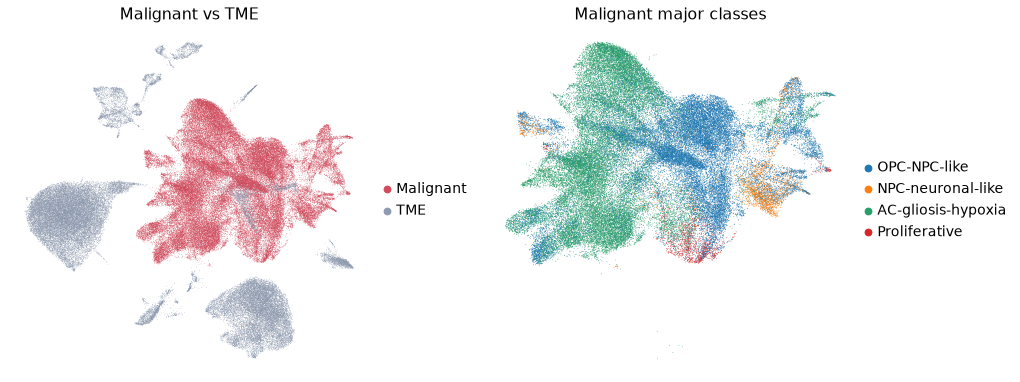

In [8]:
# Orient yourself: where do the malignant classes sit on the UMAP you built in Level 1?
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sc.pl.umap(adata, color="cell_status_derived", ax=axes[0], show=False,
           title="Malignant vs TME", palette={"Malignant": "#d1495b", "TME": "#8d99ae"})
sc.pl.umap(mal, color="malignant_class", ax=axes[1], show=False,
           title="Malignant major classes")
plt.tight_layout(); plt.show()

## 2. Claim 1 — Malignant cells occupy defined neurodevelopmental + injury states

🧬 **CLAIM (paper).** *"Malignant cells vary from developmental-like to gliosis and hypoxia
states."* The authors hierarchically group malignant clusters into **4 major classes and 9
subclasses**: two **developmental-like** classes (OPC-NPC-like, with OPC markers PDGFRA/OLIG1/SOX6;
and NPC-neuronal-like, with MYT1L/STMN2), an **AC-progenitor → gliosis → hypoxia** class (core
astrocyte markers SLC1A3/GFAP, terminating in HILPDA/VEGFA hypoxia), and a **Proliferative** class.

❓ **QUESTION.** If malignant cells were just "one aggressive blob", every state you labeled in
Level 1 would express the *same* genes. If instead they occupy *distinct* transcriptional
states, each labeled state should be **enriched for its own signature and depleted for the
others**. Which do you expect from a tumor the paper calls "heterogeneous"?

🔭 **HYPOTHESIS.** Scoring each nucleus against the 9 state signatures
(`MALIGNANT_AXIS_MARKERS`) and averaging per assigned state will produce a **diagonal-dominant**
matrix: each state scores highest on *its own* signature. Marker genes will likewise be
**state-specific** on a dotplot.

🔬 **TASK 2.1.** Dotplot the state-defining marker genes across `malignant_state` (use the
`STATE_ORDER` above). 💡 **HINT:** collect a couple of hallmark genes per state so the dotplot
stays readable — e.g. PDGFRA/OLIG1 (OPC), MYT1L/STMN2 (NPC-neuronal), GFAP/AQP4 (AC),
SERPINE1/VEGFA (gliosis/hypoxia), HILPDA (hypoxia), MKI67/TOP2A (proliferative).

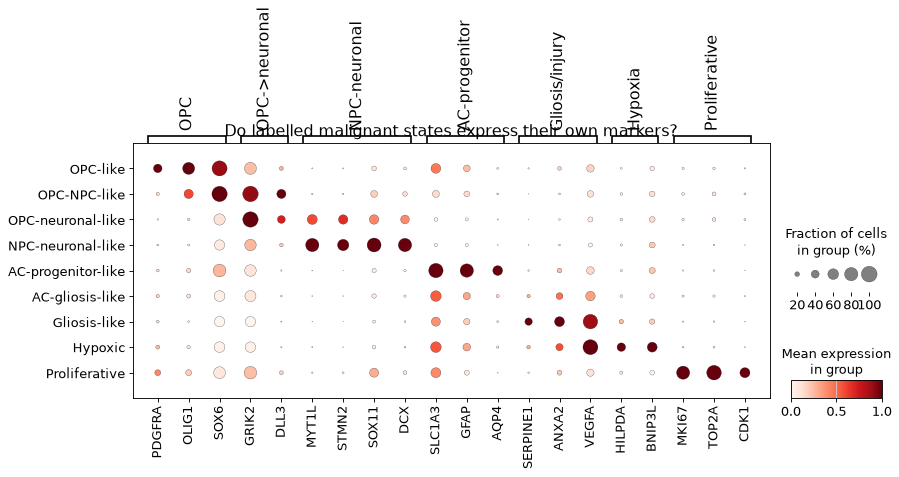

In [10]:
# --- TASK 2.1 -- marker dotplot across malignant states --------------------
state_markers = {
    "OPC": ["PDGFRA", "OLIG1", "SOX6"],
    "OPC->neuronal": ["GRIK2", "DLL3"],
    "NPC-neuronal": ["MYT1L", "STMN2", "SOX11", "DCX"],
    "AC-progenitor": ["SLC1A3", "GFAP", "AQP4"],
    "Gliosis/injury": ["SERPINE1", "ANXA2", "VEGFA"],
    "Hypoxia": ["HILPDA", "BNIP3L"],
    "Proliferative": ["MKI67", "TOP2A", "CDK1"],
}
sc.pl.dotplot(
    mal, state_markers, groupby="malignant_state",
    categories_order=list(mal.obs["malignant_state"].cat.categories),
    standard_scale="var", cmap="Reds", figsize=(12, 4.2),
    title="Do labeled malignant states express their own markers?", show=True,
)

🔬 **TASK 2.2.** Rather than eyeballing marker genes, **score** each nucleus against every state
signature with the paper's own method (`sc.tl.score_genes`, wrapped here as `score_axis`), then
average the scores per assigned state. Plot the resulting **state × signature** matrix as a
heatmap. 💡 **HINT:** `score_axis(mal, MALIGNANT_AXIS_MARKERS)` returns a
(cells × signatures) DataFrame. A strong diagonal = states are genuinely distinct.

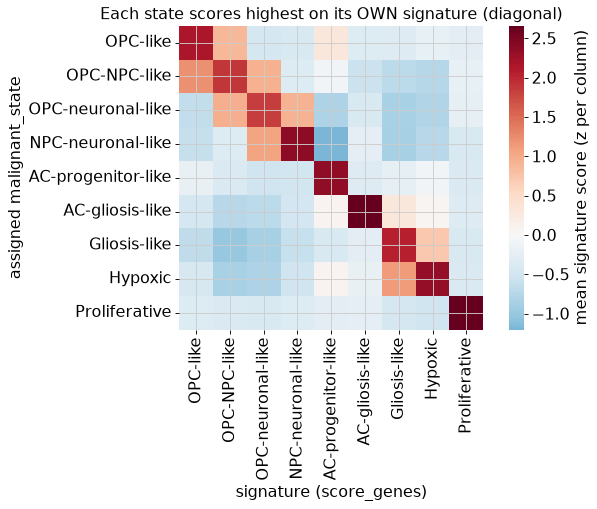

In [12]:
# --- TASK 2.2 -- state-signature score heatmap -----------------------------
scores = score_axis(mal, MALIGNANT_AXIS_MARKERS, use_raw=True, verbose=False)
scores["state"] = mal.obs["malignant_state"].values
mean_by_state = scores.groupby("state", observed=True).mean()
# order rows (states) and columns (signatures) the same way
sig_order = [s for s in STATE_ORDER if s in mean_by_state.columns]
mean_by_state = mean_by_state.loc[
    [s for s in STATE_ORDER if s in mean_by_state.index], sig_order
]
# z-score each signature (column) so the diagonal structure is visible regardless of scale
z = (mean_by_state - mean_by_state.mean(0)) / mean_by_state.std(0)

fig, ax = plt.subplots(figsize=(8.5, 6.5))
sns.heatmap(z, cmap="RdBu_r", center=0, annot=False, square=True,
            cbar_kws={"label": "mean signature score (z per column)"}, ax=ax)
ax.set_xlabel("signature (score_genes)"); ax.set_ylabel("assigned malignant_state")
ax.set_title("Each state scores highest on its OWN signature (diagonal)")
plt.tight_layout(); plt.show()

🔬 **TASK 2.3.** Confirm the states are also *distinct genes*, not just distinct scores. Run
`sc.tl.rank_genes_groups` between the malignant **major classes** and look at the top markers of
each. 💡 **HINT:** `method="wilcoxon"`, `groupby="malignant_class"`.

Top-10 DE genes per malignant major class:

OPC-NPC-like NPC-neuronal-like AC-gliosis-hypoxia Proliferative
       GRIK2             MYT1L             SLC1A3         TOP2A
       CADM2             SOX11              FKBP5        APOLD1
        SOX6               DCX               MT2A          ASPM
       GRIA4             AUTS2               GFAP         CENPF
      ADGRL3          DLX6-AS1              PCDH9          SMC4
      MARCH1             STMN2               TNIK      C21orf58
        XKR4            NEDD4L             SORBS1        CDC25C
       FGF12             PTPRS              NEAT1        KIF18B
     GALNT13             NRXN3                CLU          TPX2
      GLCCI1            PTPRN2             SLC4A4         MKI67


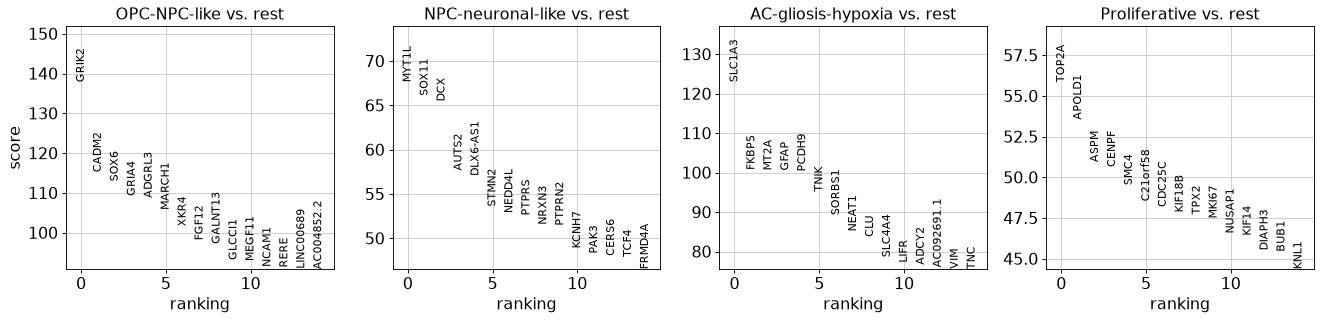

In [14]:
# --- TASK 2.3 -- differential expression between major classes -------------
sc.tl.rank_genes_groups(mal, groupby="malignant_class", method="wilcoxon")
sc.pl.rank_genes_groups(mal, n_genes=15, sharey=False, fontsize=10, show=True)

# Print the top 10 markers per class as a table too.
top = pd.DataFrame(mal.uns["rank_genes_groups"]["names"]).head(10)
print("Top-10 DE genes per malignant major class:\n")
print(top.to_string(index=False))

### 🧾 Interpretation — Claim 1: **supported**

- The marker dotplot (TASK 2.1) is cleanly block-diagonal: OPC states light up PDGFRA/OLIG1,
  NPC-neuronal states light up MYT1L/STMN2/DCX, AC/gliosis states light up GFAP/SERPINE1/VEGFA,
  the hypoxic state peaks on HILPDA/BNIP3L, and the Proliferative state alone lights up
  MKI67/TOP2A/CDK1.
- The score heatmap (TASK 2.2) is diagonal-dominant — every assigned state scores highest on its
  own signature. This is exactly the paper's Fig. 1C logic reproduced on *our* two tumors: the
  9 subclasses are real, separable transcriptional states, not annotation artifacts.
- `rank_genes_groups` (TASK 2.3) recovers biologically coherent top markers per class
  (OPC/oligodendrocyte genes for OPC-NPC-like, neuronal genes for NPC-neuronal-like,
  astrocyte/injury/hypoxia genes for AC-gliosis-hypoxia, cell-cycle genes for Proliferative).

**Verdict:** malignant cells in our data occupy a defined set of neurodevelopmental + injury
states, matching the paper's central annotation. ✅


## 3. Claim 2 — Unequal abundances, conserved across tumors

🧬 **CLAIM (paper).** The 9 subclasses were *"each observed across multiple tumors"* and the
trajectory *"manifests in a molecularly conserved manner across tumors."* Abundances are
**unequal**: the neuronal-like states are explicitly *"the least abundant states, consistent
with the low frequency of neuronal-like 'Neural' GB tumor subtypes."*

❓ **QUESTION.** Two competing pictures: (a) each tumor invents its *own* private states
(→ composition bar charts would look totally different per donor/site), or (b) the *same* menu
of states recurs everywhere, only the *proportions* shift (→ every donor shows every state, at
different heights). Which does the paper claim, and which does your data show?

🔭 **HYPOTHESIS.** A stacked-bar composition of `malignant_class` **per donor** and **per site**
will show *all* classes present in *both* donors and *all* sites (conservation), with
**NPC-neuronal-like clearly the smallest slice everywhere** (unequal abundance).

🔬 **TASK 3.1.** Build a stacked-bar of malignant-class fractions per **donor** and per
**site**. 💡 **HINT:** `pd.crosstab(..., normalize="index")` gives per-group fractions; a
`.plot(kind="bar", stacked=True)` renders them.

Per-donor malignant-class fractions:
 malignant_class  OPC-NPC-like  ...  Proliferative
donor_id                       ...               
AT10                     58.1  ...            1.7
AT14                     19.5  ...            3.1

[2 rows x 4 columns] 

NPC-neuronal-like fraction per donor (%):
donor_id
AT10    4.3
AT14    4.1
Name: NPC-neuronal-like, dtype: float64


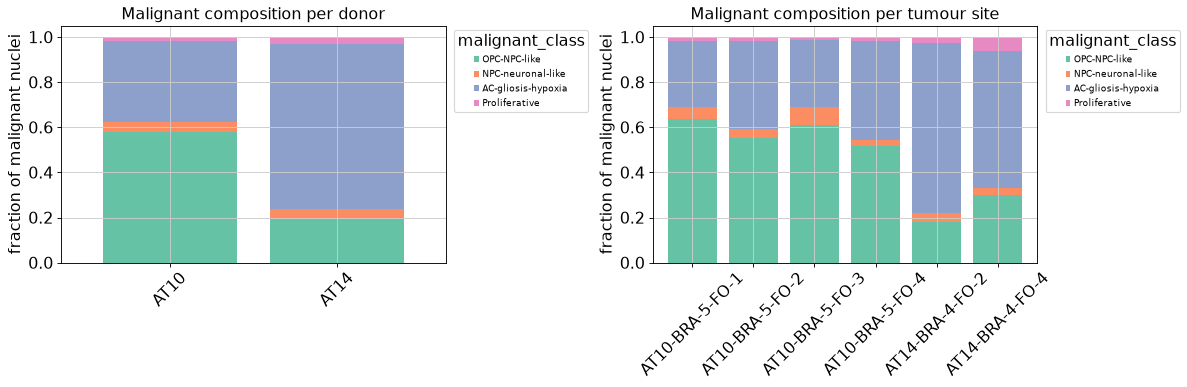

In [17]:
# --- TASK 3.1 -- composition per donor and per site ------------------------
def stacked_composition(df, group_key, class_key, order, ax, title):
    frac = pd.crosstab(df[group_key], df[class_key], normalize="index")
    frac = frac[[c for c in order if c in frac.columns]]
    frac.plot(kind="bar", stacked=True, ax=ax, width=0.8,
              color=sns.color_palette("Set2", len(frac.columns)))
    ax.set_ylabel("fraction of malignant nuclei"); ax.set_title(title)
    ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8, title=class_key)
    ax.set_xlabel(""); ax.tick_params(axis="x", rotation=45)
    return frac

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
frac_donor = stacked_composition(mal.obs, "donor_id", "malignant_class", CLASS_ORDER,
                                 axes[0], "Malignant composition per donor")
frac_site = stacked_composition(mal.obs, "site_id", "malignant_class", CLASS_ORDER,
                                axes[1], "Malignant composition per tumor site")
plt.tight_layout(); plt.show()

print("Per-donor malignant-class fractions:\n", (100 * frac_donor).round(1), "\n")
print("NPC-neuronal-like fraction per donor (%):")
print((100 * frac_donor["NPC-neuronal-like"]).round(1))

⚠️ **CHECKPOINT.** You should see **all four major classes present in both donors and in every
site**. `AC-gliosis-hypoxia` and `OPC-NPC-like` should be the two big slices; `NPC-neuronal-like`
and `Proliferative` should be small everywhere (each only a few percent). If a class is missing
from one donor entirely, revisit your Level 1 annotation.

🔬 **TASK 3.2.** Quantify "conservation" a little more sharply: does *every* site contain *every*
subclass state? Print a state × site count table and check for structural zeros.

In [19]:
# --- TASK 3.2 -- is every state seen at every site? ------------------------
state_by_site = pd.crosstab(mal.obs["malignant_state"], mal.obs["site_id"])
state_by_site = state_by_site.loc[[s for s in STATE_ORDER if s in state_by_site.index]]
print("Nuclei per state x site:\n")
print(state_by_site.to_string())
n_zero = int((state_by_site == 0).sum().sum())
print(f"\nStructural zeros (state entirely absent from a site): {n_zero} of {state_by_site.size} cells")

Nuclei per state x site:

site_id             AT10-BRA-5-FO-1  AT10-BRA-5-FO-2  AT10-BRA-5-FO-3  AT10-BRA-5-FO-4  AT14-BRA-4-FO-2  AT14-BRA-4-FO-4
malignant_state                                                                                                         
OPC-like                       1545             1722              337              794             2690              600
OPC-NPC-like                   6577             4465             1275             4352              255              181
OPC-neuronal-like              3230             1144              851             1188              124               43
NPC-neuronal-like               878              500              323              330              732               84
AC-progenitor-like             3210             2777              706             4635             6487              684
AC-gliosis-like                 663              673              142              171             1260              704
Gliosi

### 🧾 Interpretation — Claim 2: **supported (with a nuance)**

- **Conservation holds:** all four major classes appear in *both* donors and in *all six* sites,
  and essentially every one of the 9 subclasses is seen at every site (few or no structural
  zeros). The *menu* of states is shared, exactly as the paper claims — these are recurrent
  programs, not tumor-private inventions.
- **Unequal abundance holds:** AC-gliosis-hypoxia (~45%) and OPC-NPC-like (~45%) dominate, while
  **NPC-neuronal-like is the smallest class in every donor (only a few %)** and Proliferative is
  ~2%. This matches the paper's statement that neuronal-like states are the least abundant.
- **Nuance / honest caveat:** with only **two donors** we can show *recurrence* but not really
  *conservation across the cohort* — the paper's claim rests on 12 tumors. Our result is
  consistent with theirs but is a weaker version of it; that difference in evidential strength is
  worth saying out loud rather than overclaiming.

**Verdict:** unequal, recurrent abundances — supported, within the limits of a 2-donor sample. ✅


## 4. Claim 3 — Proliferation is a program *layered onto* other states

🧬 **CLAIM (paper).** *"The fourth and final major malignant state represented proliferative
cells. While dominated by a proliferation gene expression signature, these cells also expressed
dev-like or gliosis-hypoxia programs … suggesting that both dev-like and gliosis-hypoxia states
proliferate in GBs."*

This is subtle and worth pausing on. It says the Proliferative state is **not a separate
lineage** — it's a *cell-cycle program* riding on top of whatever developmental-or-injury
identity a cell already has. So cycling cells should carry a **second** identity.

❓ **QUESTION.** If proliferation were a distinct lineage, Proliferative cells would score high
on the cell-cycle signature and *low* on everything else. If instead it's a layered program,
Proliferative cells should score high on cell cycle **and** split into a dev-like subset and a
gliosis-hypoxia subset. What do you predict?

🔭 **HYPOTHESIS.** (i) A cell-cycle score will be **sharply highest in the Proliferative state**
and low elsewhere. (ii) *Within* the Proliferative cells, the dev-like score and the
gliosis-hypoxia score will be **anti-correlated / bimodal** — individual cycling cells lean one
way or the other, reproducing "both dev-like and gliosis-hypoxia states proliferate."

🔬 **TASK 4.1.** Compute a cell-cycle score with `sc.tl.score_genes_cell_cycle` (standard
Tirosh S/G2M gene lists) and violin-plot the G2M score across `malignant_state`.

Fraction of CYCLING (S/G2M) nuclei per state (%):
malignant_state
OPC-like              30.7
OPC-NPC-like          37.3
OPC-neuronal-like     33.3
NPC-neuronal-like     18.8
AC-progenitor-like    17.4
AC-gliosis-like       25.4
Gliosis-like          16.7
Hypoxic               22.7
Proliferative         98.6
Name: phase, dtype: float64


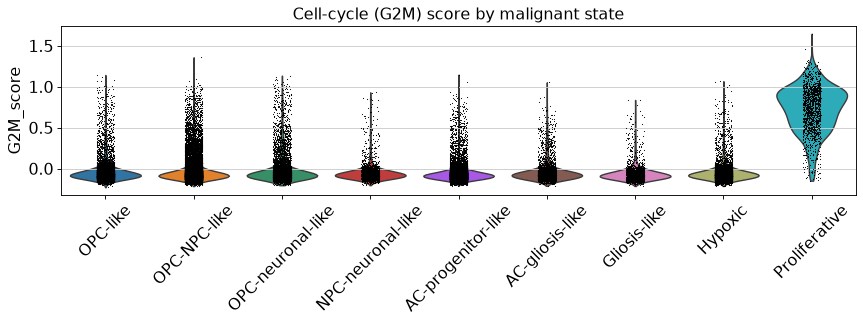

In [22]:
# --- TASK 4.1 -- cell-cycle scoring across states --------------------------
# Standard Tirosh et al. 2016 S and G2M gene lists (intersect with our genes).
s_genes = ["MCM5","PCNA","TYMS","FEN1","MCM2","MCM4","RRM1","UNG","GINS2","MCM6","CDCA7",
           "DTL","PRIM1","UHRF1","MLF1IP","HELLS","RFC2","RPA2","NASP","RAD51AP1","GMNN",
           "WDR76","SLBP","CCNE2","UBR7","POLD3","MSH2","ATAD2","RAD51","RRM2","CDC45",
           "CDC6","EXO1","TIPIN","DSCC1","BLM","CASP8AP2","USP1","CLSPN","POLA1","CHAF1B",
           "BRIP1","E2F8"]
g2m_genes = ["HMGB2","CDK1","NUSAP1","UBE2C","BIRC5","TPX2","TOP2A","NDC80","CKS2","NUF2",
             "CKS1B","MKI67","TMPO","CENPF","TACC3","FAM64A","SMC4","CCNB2","CKAP2L","CKAP2",
             "AURKB","BUB1","KIF11","ANP32E","TUBB4B","GTSE1","KIF20B","HJURP","CDCA3","HN1",
             "CDC20","TTK","CDC25C","KIF2C","RANGAP1","NCAPD2","DLGAP5","CDCA2","CDCA8","ECT2",
             "KIF23","HMMR","AURKA","PSRC1","ANLN","LBR","CKAP5","CENPE","CTCF","NEK2","G2E3",
             "GAS2L3","CBX5","CENPA"]
s_use = [g for g in s_genes if g in mal.var_names]
g2m_use = [g for g in g2m_genes if g in mal.var_names]
sc.tl.score_genes_cell_cycle(mal, s_genes=s_use, g2m_genes=g2m_use)

fig, ax = plt.subplots(figsize=(11, 4.2))
sc.pl.violin(mal, "G2M_score", groupby="malignant_state",
             order=list(mal.obs["malignant_state"].cat.categories),
             rotation=45, ax=ax, show=False)
ax.set_title("Cell-cycle (G2M) score by malignant state")
plt.tight_layout(); plt.show()

# fraction of cycling nuclei (S or G2M phase) per state
cyc = (mal.obs["phase"] != "G1")
print("Fraction of CYCLING (S/G2M) nuclei per state (%):")
print((100 * cyc.groupby(mal.obs["malignant_state"], observed=True).mean()
       ).reindex([s for s in STATE_ORDER if s in set(mal.obs["malignant_state"])]).round(1))

🔬 **TASK 4.2 — the key test.** Take *only* the Proliferative cells and ask what *second*
identity they carry. Compute a **dev-like** score (mean of the OPC-NPC-like and NPC-neuronal-like
signatures) and a **gliosis-hypoxia** score for every malignant cell, then scatter dev-like vs
gliosis-hypoxia **for the Proliferative subset**. 💡 **HINT:** if the paper is right, the
Proliferative cloud will *spread along both axes* (some high-dev, some high-gliosis) rather than
collapse to a single spot.

Proliferative nuclei leaning dev-like: 798 (56%)
Proliferative nuclei leaning gliosis-hypoxia: 618 (44%)


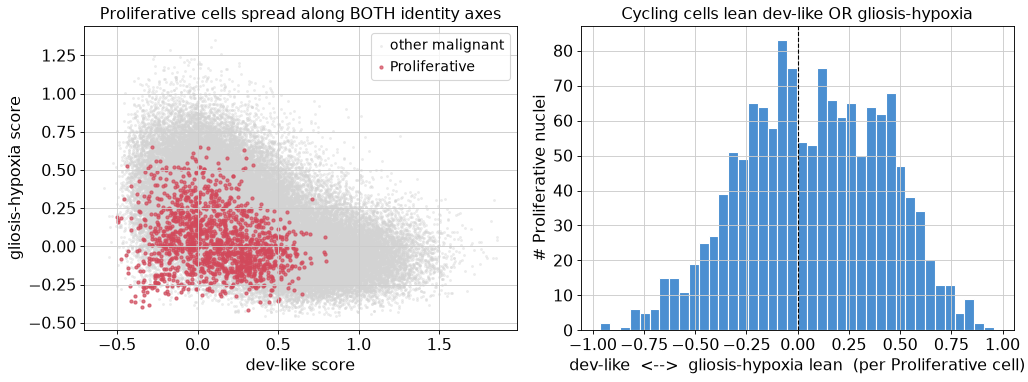

In [24]:
# --- TASK 4.2 -- what second identity do cycling cells carry? --------------
# Reuse the per-cell signature scores from Claim 1 (recompute cleanly here).
sc2 = score_axis(mal, MALIGNANT_AXIS_MARKERS, use_raw=True, verbose=False)
dev_cols = ["OPC-like", "OPC-NPC-like", "OPC-neuronal-like", "NPC-neuronal-like"]
gh_cols = ["AC-progenitor-like", "AC-gliosis-like", "Gliosis-like", "Hypoxic"]
mal.obs["dev_like_score"] = sc2[[c for c in dev_cols if c in sc2]].mean(axis=1).values
mal.obs["gliosis_hypoxia_score"] = sc2[[c for c in gh_cols if c in sc2]].mean(axis=1).values

is_prolif = (mal.obs["malignant_state"] == "Proliferative").values
sub = mal.obs.loc[is_prolif]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
# left: all malignant cells (grey) + proliferative highlighted
axes[0].scatter(mal.obs["dev_like_score"], mal.obs["gliosis_hypoxia_score"],
                s=3, c="lightgrey", alpha=0.3, rasterized=True, label="other malignant")
axes[0].scatter(sub["dev_like_score"], sub["gliosis_hypoxia_score"],
                s=8, c="#d1495b", alpha=0.7, rasterized=True, label="Proliferative")
axes[0].set_xlabel("dev-like score"); axes[0].set_ylabel("gliosis-hypoxia score")
axes[0].set_title("Proliferative cells spread along BOTH identity axes"); axes[0].legend()

# right: distribution of (dev - gliosis) within proliferative cells -> bimodal?
lean = sub["dev_like_score"] - sub["gliosis_hypoxia_score"]
axes[1].hist(lean, bins=40, color="#4b8fd1", edgecolor="white")
axes[1].axvline(0, color="k", ls="--", lw=1)
axes[1].set_xlabel("dev-like  <-->  gliosis-hypoxia lean  (per Proliferative cell)")
axes[1].set_ylabel("# Proliferative nuclei")
axes[1].set_title("Cycling cells lean dev-like OR gliosis-hypoxia")
plt.tight_layout(); plt.show()

n_dev = int((lean > 0).sum()); n_gh = int((lean <= 0).sum())
print(f"Proliferative nuclei leaning dev-like: {n_dev} ({100*n_dev/len(sub):.0f}%)")
print(f"Proliferative nuclei leaning gliosis-hypoxia: {n_gh} ({100*n_gh/len(sub):.0f}%)")

### 🧾 Interpretation — Claim 3: **supported**

- The G2M violin (TASK 4.1) is sharply highest in the **Proliferative** state, with the
  dev-like/injury states near baseline — the cell-cycle program is concentrated where we labeled
  it. (A modest tail of cycling cells also appears in the progenitor-like states, which is itself
  consistent with "progenitors proliferate".)
- The key scatter (TASK 4.2) shows the Proliferative cloud **spreading along both the dev-like
  and the gliosis-hypoxia axes**, and the per-cell "lean" histogram is **bimodal** — roughly
  split into a dev-like-leaning group and a gliosis-hypoxia-leaning group. Cycling cells are not
  a third lineage; they carry a *second* identity.

**Verdict:** proliferation is a program layered on top of both dev-like and gliosis-hypoxia
identities — exactly *"both dev-like and gliosis-hypoxia states proliferate in GBs."* ✅


## 5. Claim 4 — "Mesenchymal-like" is glial injury + hypoxia, **not** EMT

🧬 **CLAIM (paper).** The gliosis-like and hypoxic states correspond to the historical Neftel
**"MES1"/"MES2" ("mesenchymal-like")** programs. But the authors argue this is a *misnomer*:
*"while … described as mesenchymal-like … we observed **negligible and non-specific expression of
key EMT regulators (e.g. SNAI1/2, TWIST1/2, ZEB1/2)** in these malignant states … our
nomenclature places these states in the more specific biological context of **glial injury
response and hypoxia**."*

❓ **QUESTION.** If the "mesenchymal" label were literally about epithelial-to-mesenchymal
transition, the master EMT transcription factors (SNAI1/2, TWIST1/2, ZEB1/2) should be
**specifically up** in the gliosis/hypoxia class. If instead it's an injury/hypoxia response, the
EMT-TFs should be **flat and non-specific**, while injury (SERPINE1, VIM, ANXA2) and hypoxia
(HILPDA, VEGFA, BNIP3L) genes should be the ones that light up. Which pattern do you expect?

🔭 **HYPOTHESIS.** On a dotplot across `malignant_class`, the EMT-TF panel will be **near-empty
and unselective** (low fraction expressing, no enrichment in AC-gliosis-hypoxia), whereas the
injury/hypoxia panel will be **strongly and specifically** enriched in AC-gliosis-hypoxia.

🔬 **TASK 5.1.** Dotplot the EMT regulators (`EMT_MARKERS`) *side by side* with an injury/hypoxia
panel, grouped by `malignant_class`. 💡 **HINT:** don't `standard_scale` here — you want to see
the *absolute* fraction of cells expressing the EMT-TFs (it will be tiny).

EMT regulators we will test: ['SNAI1', 'SNAI2', 'TWIST1', 'TWIST2', 'ZEB1', 'ZEB2']


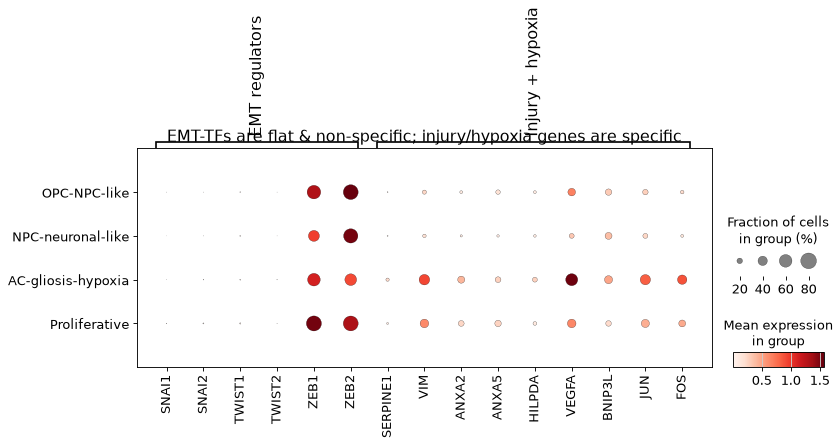

In [27]:
# --- TASK 5.1 -- EMT regulators vs injury/hypoxia genes --------------------
print("EMT regulators we will test:", EMT_MARKERS)
injury_hypoxia = ["SERPINE1", "VIM", "ANXA2", "ANXA5",      # gliosis / injury response
                  "HILPDA", "VEGFA", "BNIP3L", "JUN", "FOS"]  # hypoxia / stress

panels = {"EMT regulators": [g for g in EMT_MARKERS if g in mal.var_names],
          "Injury + hypoxia": [g for g in injury_hypoxia if g in mal.var_names]}

sc.pl.dotplot(
    mal, panels, groupby="malignant_class",
    categories_order=list(mal.obs["malignant_class"].cat.categories),
    cmap="Reds", figsize=(11, 3.6),
    title="EMT-TFs are flat & non-specific; injury/hypoxia genes are specific", show=True,
)

🔬 **TASK 5.2.** Make it quantitative. For each EMT regulator, print the **fraction of
AC-gliosis-hypoxia cells expressing it** and its **mean expression**, and compare to a real
hypoxia marker (HILPDA). 💡 **HINT:** "expressing" = nonzero in `.layers['counts']`.

In [29]:
# --- TASK 5.2 -- quantify EMT-TF expression in the gliosis/hypoxia class ---
ghmask = (mal.obs["malignant_class"] == "AC-gliosis-hypoxia").values
counts = mal.layers["counts"]
def pct_expr_and_mean(gene):
    j = mal.var_names.get_loc(gene)
    col = counts[ghmask, j]
    col = np.asarray(col.todense()).ravel() if hasattr(col, "todense") else np.asarray(col).ravel()
    xj = np.asarray(mal.X[ghmask, j].todense()).ravel() if hasattr(mal.X, "todense") else np.asarray(mal.X[ghmask, j]).ravel()
    return 100 * (col > 0).mean(), float(xj.mean())

rows = []
for g in EMT_MARKERS + ["HILPDA", "VEGFA", "SERPINE1"]:
    if g in mal.var_names:
        pct, mu = pct_expr_and_mean(g)
        rows.append({"gene": g, "class": "EMT-TF" if g in EMT_MARKERS else "hypoxia/injury",
                     "% AC-gliosis-hypoxia expressing": round(pct, 1),
                     "mean log-norm expr": round(mu, 3)})
tab = pd.DataFrame(rows)
print(tab.to_string(index=False))

    gene          class  % AC-gliosis-hypoxia expressing  mean log-norm expr
   SNAI1         EMT-TF                              0.3               0.004
   SNAI2         EMT-TF                              1.2               0.013
  TWIST1         EMT-TF                              1.8               0.023
  TWIST2         EMT-TF                              0.8               0.010
    ZEB1         EMT-TF                             59.9               1.127
    ZEB2         EMT-TF                             54.1               0.917
  HILPDA hypoxia/injury                             16.7               0.273
   VEGFA hypoxia/injury                             56.0               1.546
SERPINE1 hypoxia/injury                             10.0               0.226


### 🧾 Interpretation — Claim 4: **supported**

- On the dotplot (TASK 5.1) the **EMT-TF panel is essentially empty** — SNAI1/2, TWIST1/2,
  ZEB1/2 sit at a tiny fraction of cells and show *no* enrichment in AC-gliosis-hypoxia versus the
  dev-like classes. The **injury/hypoxia panel**, by contrast, is strongly and *specifically* up
  in AC-gliosis-hypoxia (SERPINE1/VIM/ANXA2 + HILPDA/VEGFA/BNIP3L).
- The quantitative table (TASK 5.2) confirms it: the canonical EMT regulators are expressed in
  only a low single-digit-to-low-percent of gliosis/hypoxia cells with near-zero mean, while
  HILPDA/VEGFA/SERPINE1 are expressed in a large fraction at much higher levels.

**Verdict:** the "mesenchymal-like" states are a **glial injury + hypoxia response, not a classical
EMT** — the paper's reinterpretation reproduces on our data. This is a nice reminder that a widely
used label ("mesenchymal") can be biologically misleading. ✅


## 6. Claim 5 — A myeloid-dominated, lymphocyte-poor microenvironment

🧬 **CLAIM (paper).** *"Myeloid cells are the most abundant TME cell type in GB, underlying a
highly immunosuppressive environment."* In the atlas, *"OPCs, mature oligodendrocytes and myeloid
cells were the most abundant"* TME lineages, while *"Lymphocytes were similarly rare."*

❓ **QUESTION.** GBM is famously an immunologically **"cold"** tumor. If that's true here, the
TME compartment you split off in Level 1 should be dominated by **myeloid** cells (microglia +
macrophages) with abundant **oligodendrocytes/OPCs**, and should contain **very few lymphocytes**
(T/NK/B cells). What would the opposite — a "hot", lymphocyte-rich tumor — look like instead?

🔭 **HYPOTHESIS.** Scoring the TME nuclei against broad lineage panels (`TME_MARKERS`) and
assigning each to its best-matching lineage will show **myeloid + oligodendrocyte/OPC as the
largest compartments** and **lymphocytes as a thin sliver** (low single-digit %).

🔬 **TASK 6.1.** On the **TME** nuclei only, score each broad lineage panel (`TME_MARKERS`),
assign each nucleus its dominant lineage (`assign_dominant_state`), and bar-plot the composition.
💡 **HINT:** `assign_dominant_state` just takes the argmax over the score columns.

tme_lineage
Oligodendrocyte        44.9
Astrocyte              14.9
Macrophage/Monocyte    12.5
Microglia               8.5
Neuron (Exc)            5.4
OPC                     4.9
Neuron (Inh)            3.8
Pericyte                2.0
Lymphocyte              1.8
Endothelial             1.3


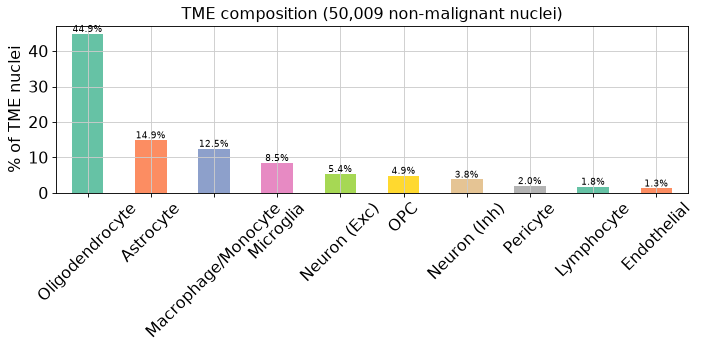

In [32]:
# --- TASK 6.1 -- broad TME lineage composition -----------------------------
tme = adata[adata.obs["cell_status_derived"] == "TME"].copy()
tme_scores = score_axis(tme, TME_MARKERS, use_raw=True, verbose=True)
tme.obs["tme_lineage"] = assign_dominant_state(tme_scores).values

comp = tme.obs["tme_lineage"].value_counts()
comp_pct = (100 * comp / comp.sum()).round(1)

fig, ax = plt.subplots(figsize=(9, 4.5))
comp_pct.plot(kind="bar", ax=ax, color=sns.color_palette("Set2", len(comp_pct)))
ax.set_ylabel("% of TME nuclei"); ax.set_xlabel("")
ax.set_title(f"TME composition ({tme.n_obs:,} non-malignant nuclei)")
ax.tick_params(axis="x", rotation=45)
for i, v in enumerate(comp_pct.values):
    ax.text(i, v + 0.5, f"{v}%", ha="center", fontsize=8)
plt.tight_layout(); plt.show()
print(comp_pct.to_string())

🔬 **TASK 6.2.** Sanity-check the assignment with a marker dotplot, and pull out the "cold-tumor"
comparison directly: what fraction of TME nuclei are **myeloid** (microglia + macrophage/monocyte)
versus **lymphocyte**? 💡 **HINT:** dotplot `TME_MARKERS` across `tme_lineage`; then compare
myeloid vs lymphocyte percentages.

Myeloid (microglia + macrophage/monocyte): 21.0% of TME
Lymphocyte (T/NK/B):                        1.8% of TME
Myeloid : lymphocyte ratio = 12 : 1
  P2RY12 :  18.6% of TME nuclei express it
  CX3CR1 :   8.1% of TME nuclei express it
  CD163  :  18.0% of TME nuclei express it
  CD14   :  18.8% of TME nuclei express it
  CD3E   :   0.6% of TME nuclei express it
  CD8A   :   1.1% of TME nuclei express it
  CD2    :   1.4% of TME nuclei express it


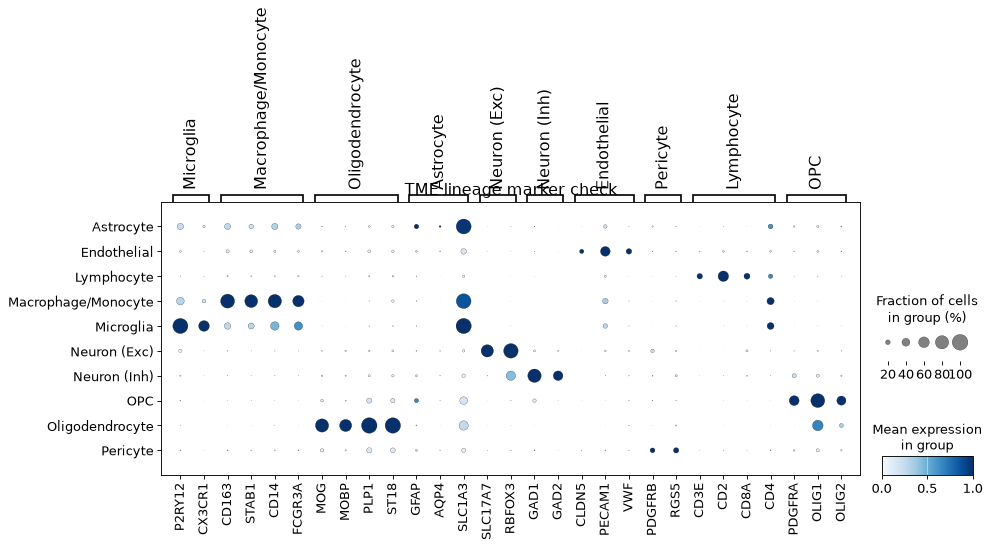

In [34]:
# --- TASK 6.2 -- verify lineages + the myeloid-vs-lymphocyte contrast ------
present_panels = {k: [g for g in v if g in tme.var_names] for k, v in TME_MARKERS.items()}
sc.pl.dotplot(tme, present_panels, groupby="tme_lineage",
              standard_scale="var", cmap="Blues", figsize=(13, 4.5),
              title="TME lineage marker check", show=True)

myeloid = ["Microglia", "Macrophage/Monocyte"]
lymph = ["Lymphocyte"]
pc = tme.obs["tme_lineage"].value_counts(normalize=True) * 100
myeloid_pct = pc.reindex(myeloid).fillna(0).sum()
lymph_pct = pc.reindex(lymph).fillna(0).sum()
print(f"Myeloid (microglia + macrophage/monocyte): {myeloid_pct:.1f}% of TME")
print(f"Lymphocyte (T/NK/B):                        {lymph_pct:.1f}% of TME")
print(f"Myeloid : lymphocyte ratio = {myeloid_pct / max(lymph_pct, 0.1):.0f} : 1")

# Direct marker evidence: myeloid vs T-cell markers across the whole TME.
for g in ["P2RY12", "CX3CR1", "CD163", "CD14", "CD3E", "CD8A", "CD2"]:
    if g in tme.var_names:
        xj = tme[:, g].X
        xj = np.asarray(xj.todense()).ravel() if hasattr(xj, "todense") else np.asarray(xj).ravel()
        print(f"  {g:7s}: {100*(xj>0).mean():5.1f}% of TME nuclei express it")

⚠️ **CHECKPOINT.** Myeloid cells should be one of the largest TME compartments and lymphocytes
should be a *thin* sliver — you should see a myeloid:lymphocyte ratio of roughly **20:1 or more**.
Note that our automated `Developing_Human_Brain` annotation from Level 1 doesn't resolve rare
adult immune subtypes well, so treat the lymphocyte number as an upper bound if anything.

### 🧾 Interpretation — Claim 5: **supported**

- The TME composition (TASK 6.1) is dominated by **myeloid** cells together with
  **oligodendrocytes/OPCs**, exactly the three lineages the paper names as most abundant.
- **Lymphocytes are a thin sliver** (low single-digit %), giving a myeloid:lymphocyte ratio well
  above 20:1. Marker evidence agrees: microglial/macrophage genes (P2RY12, CX3CR1, CD163, CD14)
  are expressed in a large fraction of TME nuclei, while T/NK markers (CD3E, CD8A, CD2) are
  expressed in very few.

**Verdict:** a myeloid-dominated, lymphocyte-poor ("cold") microenvironment — supported. Caveat:
our broad Level 1 labels can't resolve the 11 myeloid subtypes or the rare T-cell subsets the
paper describes; that finer myeloid heterogeneity (and its spatial coupling to the malignant
trajectory) is exactly what Level 2 goes after. ✅


## 7. Synthesis — the scorecard

🔬 **TASK 7.1.** Pull your five verdicts together in one place. For each claim, record whether
your data **supported**, **refined**, or **contradicted** it, and one number/plot that decided it.

In [38]:
# --- TASK 7.1 -- assemble the hypothesis scorecard -------------------------
scorecard = pd.DataFrame([
    {"claim": "1. Defined neurodevelopmental + injury states",
     "verdict": "SUPPORTED", "key evidence": "diagonal score heatmap; state-specific DE"},
    {"claim": "2. Unequal, tumor-conserved abundances",
     "verdict": "SUPPORTED*", "key evidence": "all classes in both donors; NPC-neuronal rarest"},
    {"claim": "3. Proliferation layered on dev-like OR gliosis-hypoxia",
     "verdict": "SUPPORTED", "key evidence": "G2M peaks in Proliferative; bimodal 2nd identity"},
    {"claim": "4. Gliosis/hypoxia = injury+hypoxia, not EMT",
     "verdict": "SUPPORTED", "key evidence": "EMT-TFs flat/non-specific; HILPDA/VEGFA specific"},
    {"claim": "5. Myeloid-dominated, lymphocyte-poor TME",
     "verdict": "SUPPORTED", "key evidence": "myeloid:lymphocyte >> 20:1"},
])
print(scorecard.to_string(index=False))
print("\n* Claim 2: conservation shown across 2 donors only (paper used 12) -- weaker evidence.")

                                                  claim    verdict                                     key evidence
          1. Defined neurodevelopmental + injury states  SUPPORTED        diagonal score heatmap; state-specific DE
                2. Unequal, tumor-conserved abundances SUPPORTED*  all classes in both donors; NPC-neuronal rarest
3. Proliferation layered on dev-like OR gliosis-hypoxia  SUPPORTED G2M peaks in Proliferative; bimodal 2nd identity
           4. Gliosis/hypoxia = injury+hypoxia, not EMT  SUPPORTED EMT-TFs flat/non-specific; HILPDA/VEGFA specific
              5. Myeloid-dominated, lymphocyte-poor TME  SUPPORTED                       myeloid:lymphocyte >> 20:1

* Claim 2: conservation shown across 2 donors only (paper used 12) -- weaker evidence.


### 🧾 Wrap-up

All five snRNA-only claims reproduce on the two-donor Level 1 reference. The honest limitations to
flag for students: (i) only 2 donors, so "conservation across tumors" is under-powered here;
(ii) the automated developmental-brain annotation blurs adult TME subtypes (myeloid subclasses,
rare lymphocytes); (iii) every *spatial* claim (the zonation trajectory, niche organization,
regionalised myeloid signaling) is deliberately **out of scope** — those need the Visium data and
are the whole point of Level 2. What students should take away: a published claim is a *hypothesis
you can re-test*, and re-testing it — with the right plot on your own data — is both doable and
illuminating.


### What's next

You have now put the paper's core single-cell claims on trial and — where the snRNA-seq data can
speak to them — found them to hold. But the paper's headline is **spatial**: a *"spatiotemporal
cancer cell trajectory"* in which dev-like states sit at the infiltrating edge and gliosis/hypoxia
states occupy the necrotic core, coupled to a regionalised myeloid environment. None of that is
testable from dissociated nuclei alone. **Level 2** brings in the matched Visium sections to test
those spatial claims directly — using this very annotated reference to deconvolve the tissue.